# Assignment 5a: Pandas Fundamentals with Earthquake Data

**At-home assignment — worth 10 points.** When you're done, push your work to your week folder and post a link to your completed **notebook** on the matching Courseworks assignment.

In this assignment you'll exercise core pandas skills on a real-world dataset: the USGS Earthquakes catalog.

:::{admonition} Learning goals
:class: tip
This assignment exercises the pandas fundamentals from this section:

- Load CSV data directly from a URL into a `DataFrame`
- Parse dates and use them as a time index
- Use `describe`, `nlargest`, and column selection to explore data
- Filter rows with boolean masks
- Create a new column derived from existing ones
- Group by a column and count entries
- Plot histograms and scatter plots directly from a DataFrame
:::

:::{admonition} Working through this notebook
:class: tip
**Download** this notebook using the ⬇ button in the top-right (or copy-paste the cells into a fresh notebook), open it in your environment (JupyterLab on LEAP or Colab), and fill in your solution under each numbered task.

When you're done, follow the [submission instructions](#submission-instructions) at the bottom of the page.
:::

Start by importing numpy, pandas, and matplotlib's pyplot (with conventional short aliases). The cell below is empty — type your imports there and run it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Data for this assignment in .csv format downloaded from the [USGS Earthquakes Database](https://earthquake.usgs.gov/earthquakes/search/) is available at:

https://raw.githubusercontent.com/earth-DS-ML/summer_2026/refs/heads/main/lectures_DS/data/usgs_earthquakes_2025.csv

You don't need to download this file. You can open it directly with Pandas.

## 1) Use Pandas' read_csv function directly on this URL to open it as a DataFrame
(Don't use any special options). Display the first few rows and the DataFrame info.

In [2]:
url = "https://raw.githubusercontent.com/earth-DS-ML/summer_2026/refs/heads/main/lectures_DS/data/usgs_earthquakes_2025.csv"
df = pd.read_csv(url)
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-06-17T12:00:22.773Z,-23.164500,-175.354900,10.0,4.90,mb,22.0,166.00,6.4810,0.4900,...,2025-06-17T12:30:04.040Z,"206 km SSW of ‘Ohonua, Tonga",earthquake,15.85,1.938,0.093,36.0,reviewed,us,us
1,2025-06-17T11:04:43.352Z,41.123400,-116.258400,3.7,2.70,ml,7.0,79.84,0.1590,0.1459,...,2025-06-17T11:28:44.047Z,"47 km NNW of Carlin, Nevada",earthquake,NaN,4.400,0.260,4.0,reviewed,nn,nn
2,2025-06-17T09:16:30.483Z,-23.118100,-174.912900,10.0,4.80,mb,16.0,111.00,6.1510,0.4800,...,2025-06-17T10:43:17.040Z,"196 km S of ‘Ohonua, Tonga",earthquake,14.94,1.939,0.148,14.0,reviewed,us,us
3,2025-06-17T09:09:53.314Z,41.114300,-116.292400,1.7,3.20,ml,16.0,63.95,0.1370,0.1140,...,2025-06-17T09:53:55.755Z,"47 km NNW of Carlin, Nevada",earthquake,NaN,2.300,0.230,10.0,reviewed,nn,nn
4,2025-06-17T08:40:41.280Z,38.046333,-118.785333,10.4,2.93,md,39.0,67.00,0.2282,0.0500,...,2025-06-17T09:41:06.390Z,"27 km SE of Bodie, CA",earthquake,0.24,1.030,0.160,40.0,reviewed,nc,nc


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10654 entries, 0 to 10653
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             10654 non-null  str    
 1   latitude         10654 non-null  float64
 2   longitude        10654 non-null  float64
 3   depth            10654 non-null  float64
 4   mag              10654 non-null  float64
 5   magType          10654 non-null  str    
 6   nst              9919 non-null   float64
 7   gap              9919 non-null   float64
 8   dmin             9918 non-null   float64
 9   rms              10654 non-null  float64
 10  net              10654 non-null  str    
 11  id               10654 non-null  str    
 12  updated          10654 non-null  str    
 13  place            10654 non-null  str    
 14  type             10654 non-null  str    
 15  horizontalError  9820 non-null   float64
 16  depthError       10653 non-null  float64
 17  magError         9868 n

You should have seen that the dates were not automatically parsed into datetime types.

## 2) Re-read the data in such a way that all date columns are identified as dates and the earthquake ID is used as the index

Verify that this worked using the `head` and `info` functions.


In [4]:
df = pd.read_csv(url, parse_dates=["time", "updated"], index_col="id")
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
id,,,,,,,,,,,,,,,,,,,,,
us6000qkt1,2025-06-17 12:00:22.773000+00:00,-23.164500,-175.354900,10.0,4.90,mb,22.0,166.00,6.4810,0.4900,...,2025-06-17 12:30:04.040000+00:00,"206 km SSW of ‘Ohonua, Tonga",earthquake,15.85,1.938,0.093,36.0,reviewed,us,us
nn00899047,2025-06-17 11:04:43.352000+00:00,41.123400,-116.258400,3.7,2.70,ml,7.0,79.84,0.1590,0.1459,...,2025-06-17 11:28:44.047000+00:00,"47 km NNW of Carlin, Nevada",earthquake,NaN,4.400,0.260,4.0,reviewed,nn,nn
us6000qksf,2025-06-17 09:16:30.483000+00:00,-23.118100,-174.912900,10.0,4.80,mb,16.0,111.00,6.1510,0.4800,...,2025-06-17 10:43:17.040000+00:00,"196 km S of ‘Ohonua, Tonga",earthquake,14.94,1.939,0.148,14.0,reviewed,us,us
nn00899041,2025-06-17 09:09:53.314000+00:00,41.114300,-116.292400,1.7,3.20,ml,16.0,63.95,0.1370,0.1140,...,2025-06-17 09:53:55.755000+00:00,"47 km NNW of Carlin, Nevada",earthquake,NaN,2.300,0.230,10.0,reviewed,nn,nn
nc75196741,2025-06-17 08:40:41.280000+00:00,38.046333,-118.785333,10.4,2.93,md,39.0,67.00,0.2282,0.0500,...,2025-06-17 09:41:06.390000+00:00,"27 km SE of Bodie, CA",earthquake,0.24,1.030,0.160,40.0,reviewed,nc,nc


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 10654 entries, us6000qkt1 to us6000plld
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             10654 non-null  datetime64[us, UTC]
 1   latitude         10654 non-null  float64            
 2   longitude        10654 non-null  float64            
 3   depth            10654 non-null  float64            
 4   mag              10654 non-null  float64            
 5   magType          10654 non-null  str                
 6   nst              9919 non-null   float64            
 7   gap              9919 non-null   float64            
 8   dmin             9918 non-null   float64            
 9   rms              10654 non-null  float64            
 10  net              10654 non-null  str                
 11  updated          10654 non-null  datetime64[us, UTC]
 12  place            10654 non-null  str                
 13  type             1

## 3) Use `describe` to get the basic statistics of all the columns

Note the highest and lowest magnitude of earthquakes in the databse.

In [6]:
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,10654.000000,10654.000000,10654.000000,10654.000000,9919.000000,9919.000000,9918.000000,10654.000000,9820.000000,10653.000000,9868.000000,9909.000000
mean,19.480071,-27.702737,62.060599,3.864279,43.145378,134.090393,2.434296,0.615406,6.947442,4.411837,0.113816,36.508629
std,31.231385,125.968773,110.250304,0.854359,37.794869,71.401092,4.100662,0.284075,4.395204,4.907911,0.055055,52.030189
min,-73.220400,-179.993300,-2.950000,2.500000,3.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.095700,-151.755725,10.000000,3.000000,19.000000,76.000000,0.501000,0.420000,3.940000,1.841027,0.078000,12.000000
50%,23.175050,-67.340900,14.565000,4.200000,31.000000,121.000000,1.294500,0.620000,6.680000,1.978000,0.105000,20.000000
75%,47.420125,120.648275,63.054000,4.500000,53.000000,187.000000,2.669500,0.810000,9.760000,6.697000,0.139000,40.000000
max,87.027900,179.985500,667.237000,7.700000,475.000000,358.180000,52.015000,1.860000,40.010000,41.322000,0.730000,892.000000


## 4) Use `nlargest` to get the top 20 earthquakes by magnitude

https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.nlargest.html

In [7]:
df.nlargest(20, "mag")

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
id,,,,,,,,,,,,,,,,,,,,,
us7000pn9s,2025-03-28 06:20:52.715000+00:00,22.0110,95.9363,10.000,7.7,mww,246.0,24.0,3.474,0.89,...,2025-06-16 19:10:14.405000+00:00,"2025 Mandalay, Burma (Myanmar) Earthquake",earthquake,7.63,1.719,0.028,121.0,reviewed,us,us
us7000pcdl,2025-02-08 23:23:14.697000+00:00,17.6506,-82.3950,14.326,7.6,mww,235.0,18.0,4.662,0.62,...,2025-04-26 15:51:49.572000+00:00,"210 km SSW of George Town, Cayman Islands",earthquake,6.99,3.216,0.028,119.0,reviewed,us,us
us7000pwkn,2025-05-02 12:58:26.014000+00:00,-56.8094,-68.1019,10.000,7.4,mww,284.0,20.0,1.900,0.75,...,2025-06-06 12:21:50.736000+00:00,2025 Drake Passage Earthquake,earthquake,7.58,1.441,0.038,68.0,reviewed,us,us
us7000pntq,2025-03-30 12:18:50.362000+00:00,-20.3036,-174.0718,29.000,7.0,mww,287.0,20.0,4.091,0.96,...,2025-06-06 21:12:28.040000+00:00,"61 km SSE of Pangai, Tonga",earthquake,4.83,2.971,0.031,98.0,reviewed,us,us
us6000q41n,2025-04-04 20:04:38.129000+00:00,-6.3025,151.6257,9.000,6.9,mww,333.0,11.0,2.022,0.78,...,2025-06-09 13:38:40.040000+00:00,"184 km ESE of Kimbe, Papua New Guinea",earthquake,5.87,1.699,0.028,121.0,reviewed,us,us
us6000q3nw,2025-04-03 14:09:29.739000+00:00,52.4538,-32.1071,10.000,6.9,mww,165.0,19.0,11.349,0.57,...,2025-06-09 13:38:39.040000+00:00,Reykjanes Ridge,earthquake,8.40,1.762,0.031,99.0,reviewed,us,us
us7000pvtr,2025-04-29 14:53:37.897000+00:00,-54.2616,155.6446,18.957,6.8,mww,475.0,11.0,1.942,0.51,...,2025-05-22 13:59:03.231000+00:00,Macquarie Island region,earthquake,7.93,2.668,0.044,49.0,reviewed,us,us
us6000pjny,2025-01-13 12:19:32.252000+00:00,31.8326,131.5525,39.000,6.8,mww,151.0,18.0,0.992,1.07,...,2025-03-20 20:55:21.040000+00:00,"15 km SE of Miyazaki, Japan",earthquake,3.70,1.827,0.033,87.0,reviewed,us,us
us7000pn9z,2025-03-28 06:32:04.777000+00:00,21.6975,95.9690,10.000,6.7,mww,106.0,41.0,4.266,0.75,...,2025-06-06 21:12:25.040000+00:00,Burma (Myanmar),earthquake,7.64,1.831,0.089,12.0,reviewed,us,us


Examine the structure of the `place` column. The state / country information seems to be in there. How would you get it out?

## 5) Extract the state or country using Pandas [text data functions](https://pandas.pydata.org/pandas-docs/stable/text.html)

Add it as a new column to the dataframe called `country`. Note that some of the "countries" are actually U.S. states.

In [8]:
df["country"] = df["place"].str.split(", ").str[-1]
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000qkt1,2025-06-17 12:00:22.773000+00:00,-23.164500,-175.354900,10.0,4.90,mb,22.0,166.00,6.4810,0.4900,...,"206 km SSW of ‘Ohonua, Tonga",earthquake,15.85,1.938,0.093,36.0,reviewed,us,us,Tonga
nn00899047,2025-06-17 11:04:43.352000+00:00,41.123400,-116.258400,3.7,2.70,ml,7.0,79.84,0.1590,0.1459,...,"47 km NNW of Carlin, Nevada",earthquake,NaN,4.400,0.260,4.0,reviewed,nn,nn,Nevada
us6000qksf,2025-06-17 09:16:30.483000+00:00,-23.118100,-174.912900,10.0,4.80,mb,16.0,111.00,6.1510,0.4800,...,"196 km S of ‘Ohonua, Tonga",earthquake,14.94,1.939,0.148,14.0,reviewed,us,us,Tonga
nn00899041,2025-06-17 09:09:53.314000+00:00,41.114300,-116.292400,1.7,3.20,ml,16.0,63.95,0.1370,0.1140,...,"47 km NNW of Carlin, Nevada",earthquake,NaN,2.300,0.230,10.0,reviewed,nn,nn,Nevada
nc75196741,2025-06-17 08:40:41.280000+00:00,38.046333,-118.785333,10.4,2.93,md,39.0,67.00,0.2282,0.0500,...,"27 km SE of Bodie, CA",earthquake,0.24,1.030,0.160,40.0,reviewed,nc,nc,CA


## 6) Display each unique value from the new column

https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.unique.html

In [9]:
df["country"].unique()

array(['Tonga', 'Nevada', 'CA', 'Philippines', 'Russia',
       'southern Mid-Atlantic Ridge', 'New Mexico', 'Ecuador',
       'Indonesia', 'Alaska', 'Papua New Guinea', 'Argentina',
       'south of the Fiji Islands', 'Japan', 'Chile', 'Mexico',
       'Washington', 'Texas', 'Greece', 'U.S. Virgin Islands',
       'southern East Pacific Rise', 'Afghanistan', 'Oman', 'Puerto Rico',
       'Yemen', 'India', 'Guatemala', 'Mid-Indian Ridge', 'Oregon',
       'Pakistan', 'Peru', 'Utah', 'China', 'Solomon Islands',
       'Timor Leste', 'Pacific-Antarctic Ridge', 'Nicaragua', 'Bolivia',
       'Idaho', 'Dominican Republic', 'South Sandwich Islands region',
       'east of Severnaya Zemlya', 'Turkey', 'Hawaii',
       'west of Macquarie Island', 'off the coast of Central America',
       'Carlsberg Ridge', 'western Indian-Antarctic Ridge',
       'Japan region', 'Anguilla', 'Vanuatu', 'Kuril Islands', 'Colorado',
       'Wallis and Futuna', 'Balleny Islands region', 'Vanuatu region',
       

## 7) Create a filtered dataset that contains only earthquakes with magnitude greater than 4

Store it in a new variable (e.g. `df_big`) — you'll reuse it in the next tasks.

In [10]:
df_big = df[df["mag"] > 4]
print(len(df_big), "earthquakes with magnitude > 4")
df_big.head()

5923 earthquakes with magnitude > 4


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000qkt1,2025-06-17 12:00:22.773000+00:00,-23.1645,-175.3549,10.000,4.9,mb,22.0,166.0,6.481,0.49,...,"206 km SSW of ‘Ohonua, Tonga",earthquake,15.85,1.938,0.093,36.0,reviewed,us,us,Tonga
us6000qksf,2025-06-17 09:16:30.483000+00:00,-23.1181,-174.9129,10.000,4.8,mb,16.0,111.0,6.151,0.48,...,"196 km S of ‘Ohonua, Tonga",earthquake,14.94,1.939,0.148,14.0,reviewed,us,us,Tonga
us6000qks2,2025-06-17 08:36:22.986000+00:00,8.2769,126.8035,34.840,5.3,mww,100.0,67.0,1.706,1.23,...,"42 km ENE of Barcelona, Philippines",earthquake,7.91,3.994,0.062,25.0,reviewed,us,us,Philippines
us6000qkrz,2025-06-17 08:13:19.239000+00:00,50.6542,156.7597,91.831,4.7,mb,55.0,152.0,2.526,0.64,...,"44 km E of Severo-Kuril’sk, Russia",earthquake,10.38,7.726,0.032,287.0,reviewed,us,us,Russia
us6000qks0,2025-06-17 08:12:55.629000+00:00,-32.8812,-13.2948,10.000,5.0,mb,44.0,59.0,4.254,0.91,...,southern Mid-Atlantic Ridge,earthquake,10.55,1.837,0.076,55.0,reviewed,us,us,southern Mid-Atlantic Ridge


## 8) Using the filtered dataset (magnitude > 4), count the number of earthquakes in each country/state. Make a bar chart of this number for the top 5 locations with the most earthquakes

Location name on the x axis, Earthquake count on the y axis

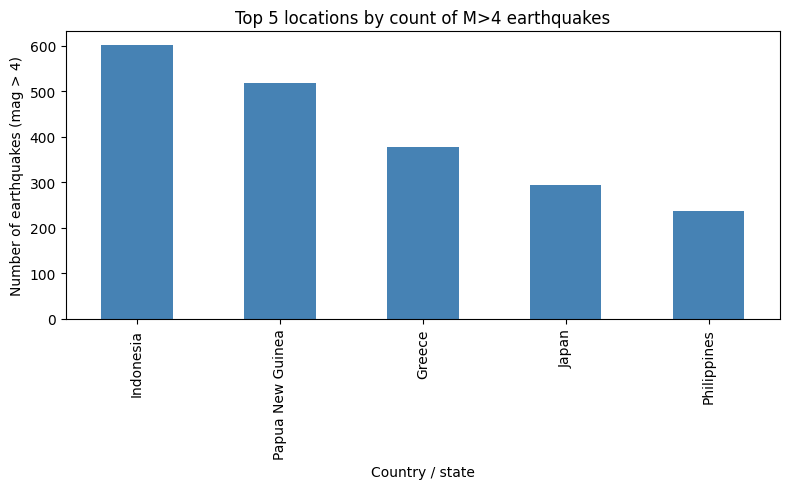

In [11]:
top5 = df_big["country"].value_counts().nlargest(5)
fig, ax = plt.subplots(figsize=(8, 5))
top5.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Country / state")
ax.set_ylabel("Number of earthquakes (mag > 4)")
ax.set_title("Top 5 locations by count of M>4 earthquakes")
plt.tight_layout()

## 9) Make a histogram the distribution of the Earthquake magnitudes

https://pandas.pydata.org/pandas-docs/version/0.23/generated/pandas.DataFrame.hist.html
https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html

Do one subplot for the filtered and one for the unfiltered dataset.
Use a Logarithmic scale. What sort of relationship do you see?

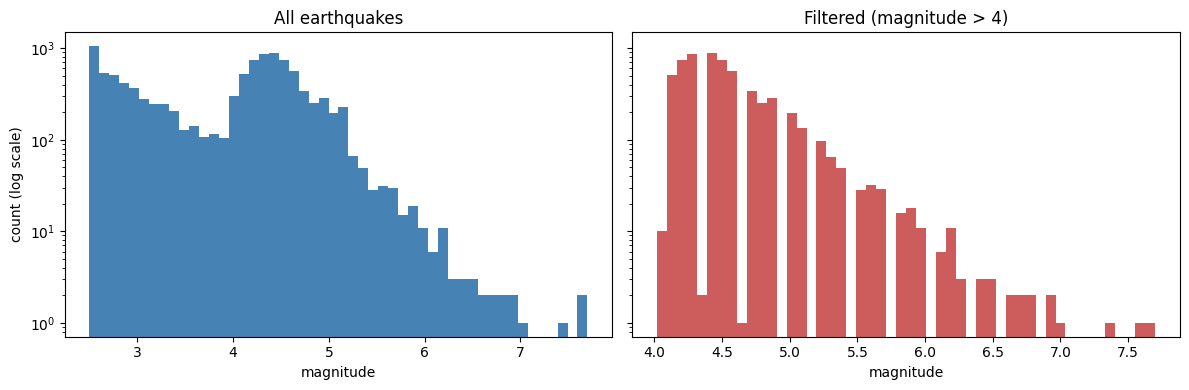

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(df["mag"].dropna(), bins=50, log=True, color="steelblue")
axes[0].set_title("All earthquakes")
axes[0].set_xlabel("magnitude"); axes[0].set_ylabel("count (log scale)")
axes[1].hist(df_big["mag"].dropna(), bins=50, log=True, color="indianred")
axes[1].set_title("Filtered (magnitude > 4)")
axes[1].set_xlabel("magnitude")
plt.tight_layout()

## 10) Visualize the locations of earthquakes by making a scatterplot of their latitude and longitude

Use a two-column subplot with both the filtered and unfiltered datasets. Color the points by magnitude. Make it pretty

What difference do you note between the filtered and unfiltered datasets?

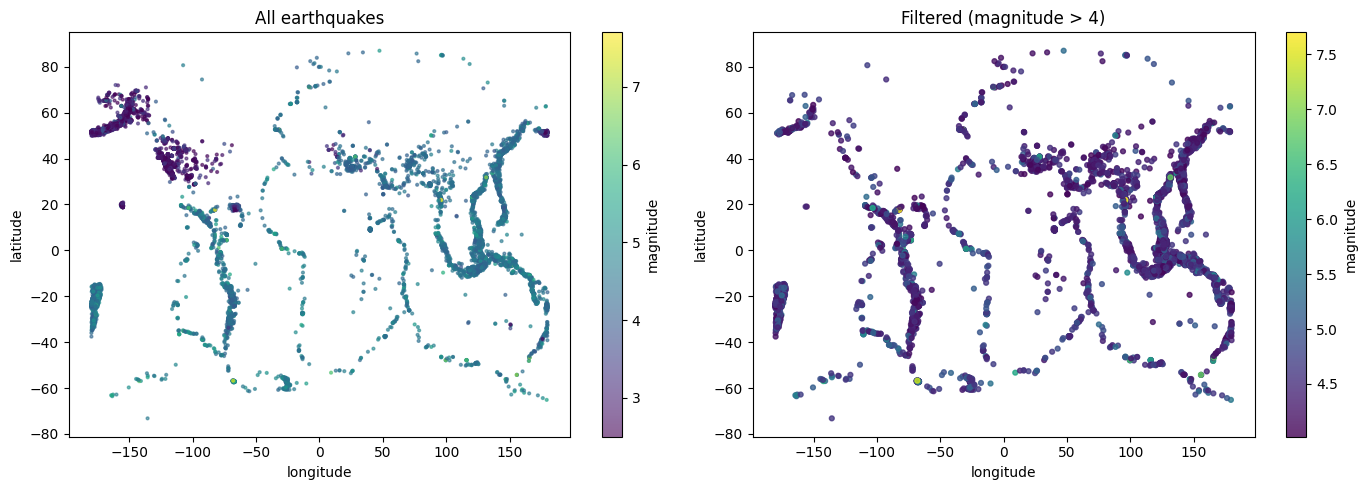

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc0 = axes[0].scatter(df["longitude"], df["latitude"], c=df["mag"],
                      s=4, cmap="viridis", alpha=0.6)
axes[0].set_title("All earthquakes"); axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")
fig.colorbar(sc0, ax=axes[0], label="magnitude")
sc1 = axes[1].scatter(df_big["longitude"], df_big["latitude"], c=df_big["mag"],
                      s=12, cmap="viridis", alpha=0.8)
axes[1].set_title("Filtered (magnitude > 4)"); axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
fig.colorbar(sc1, ax=axes[1], label="magnitude")
plt.tight_layout()

## Submission instructions

When you're done, save your completed notebook as `assignment5a.ipynb` inside the current week's folder in your private `clmt5405-assignments` GitHub repo. Then push the commit:

```bash
git add <weekN>/assignment5a.ipynb
git commit -m "Submit assignment 5a"
git push
```

Due Sunday night.